In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans


In [3]:
#load dataset
df = pd.read_csv('/content/player_stats.csv',encoding='ISO-8859-1')

used encoding (like latin1) in read_csv to correctly interpret special characters in a file when it is not stored in UTF-8 format, preventing decoding errors.

In [4]:
df

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [5]:
df.isnull().sum()

,0
player,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0


In [6]:
df = df.drop(columns=['marking'])

dropped the "marking" column because it contains only null values and provides no useful information for analysis or model building.

In [7]:
## Duplicate check

df.duplicated().sum()

np.int64(3)

In [8]:
df.drop_duplicates(inplace=True)

used drop_duplicates() to remove repeated rows and maintain clean, unique data for analysis.

In [9]:
df

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,68,73,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,56,58,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,13,16,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,66,69,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,14,16,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,41,43,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,38,42,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,29,32,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,24,32,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [10]:
# Drop player name (unique identifier)
df = df.drop(['player'], axis=1)

dropped the player name column because it is a unique identifier and does not contribute to model prediction.

In [11]:
df

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,Atl. Nacional,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,Corinthians,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
2,Germany,193,84,29,Holstein Kiel,25,12,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Austria,187,86,33,SK Rapid Wien,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
4,Uruguay,191,80,23,Independiente,14,8,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,Liverpool,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Senegal,174,69,31,FC Bayern München,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Brazil,175,68,31,Paris SG,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,Al Nassr,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [12]:
#num cols
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include = "object").columns

In [13]:
num_cols

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle',
       'stand_tackle', 'aggression', 'reactions', 'att_position',
       'interceptions', 'vision', 'composure', 'crossing', 'short_pass',
       'long_pass', 'acceleration', 'stamina', 'strength', 'balance',
       'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power',
       'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys',
       'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes'],
      dtype='object')

In [14]:
cat_cols

Index(['country', 'club', 'value'], dtype='object')

In [15]:
## Outlier removal

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3-Q1

  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR

  outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]



In [16]:
outliers

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
2,Germany,193,84,29,Holstein Kiel,25,12,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
4,Uruguay,191,80,23,Independiente,14,8,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
5,Portugal,183,83,31,FC Porto,20,16,13,17,27,...,15,13,13,10,72,78,73,64,74,$2.800.000
29,Brazil,189,76,22,Gil Vicente,14,10,17,8,24,...,10,8,21,14,68,73,70,66,74,$2.100.000
34,Argentina,185,80,30,Argentinos Jrs.,21,20,15,15,16,...,20,12,24,19,71,72,67,64,72,$1.100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5613,Argentina,189,85,26,Patronato,17,12,11,10,25,...,12,11,12,8,63,60,61,60,60,$275.00
5619,Italy,195,85,28,Hellas Verona,20,14,18,15,24,...,16,17,26,14,66,67,67,61,64,$775.00
5636,England,184,77,25,Luton Town,24,19,20,19,26,...,14,20,27,11,67,66,63,63,65,$725.00
5646,Paraguay,195,87,22,Gral. Caballero,17,6,13,14,19,...,14,14,14,8,57,60,54,50,64,$180.00


In [17]:
df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [18]:
df_clean

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,Atl. Nacional,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,Corinthians,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
3,Austria,187,86,33,SK Rapid Wien,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
6,Switzerland,194,88,25,BSC Young Boys,52,43,71,72,63,...,29,22,34,34,10,5,14,12,5,$1.600.000
7,Portugal,185,75,20,Boavista FC,41,33,65,70,46,...,26,26,39,25,7,6,12,13,11,$230.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,Liverpool,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Senegal,174,69,31,FC Bayern München,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Brazil,175,68,31,Paris SG,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,Al Nassr,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [19]:
df = df_clean

removed outliers using the IQR method to eliminate extreme values that may negatively impact model performance.


For univariate and bivariate analysis-
selecting important columns based on their relevance to the target variable and their potential influence on player market value, ensuring focused and meaningful analysis while avoiding unnecessary complexity.

these are selected because:

value → Target variable,
age → Strong factor in player valuation,
reactions → Overall gameplay intelligence,
ball_control → Technical skill,
finishing → Attacking ability

These columns represent player performance and
having high impact on market value.


In [20]:
imp_cols = ['value', 'age', 'reactions', 'ball_control', 'finishing']

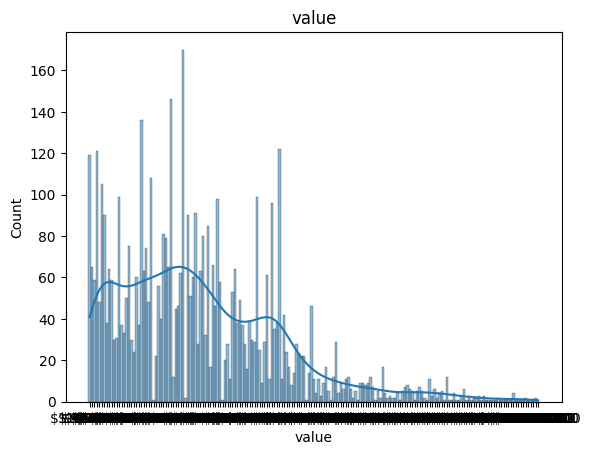

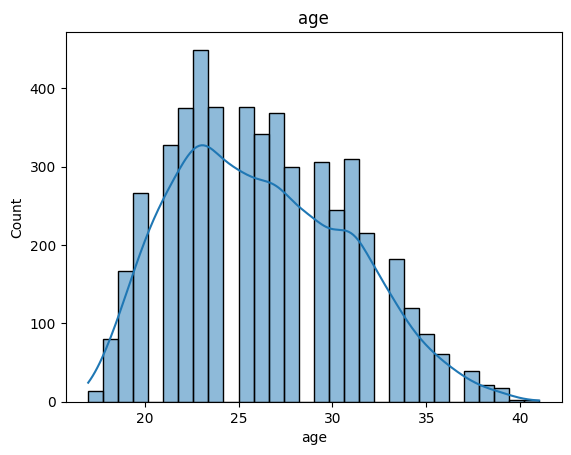

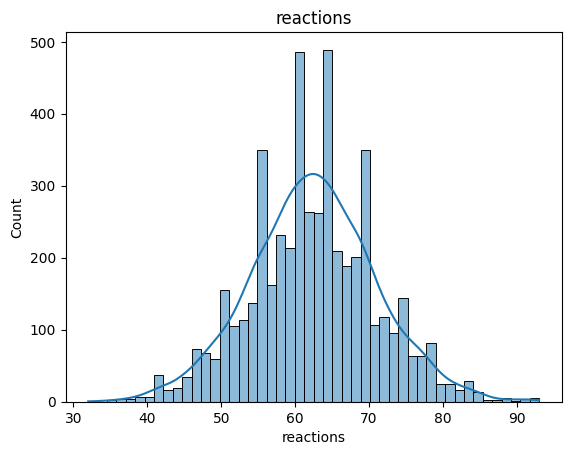

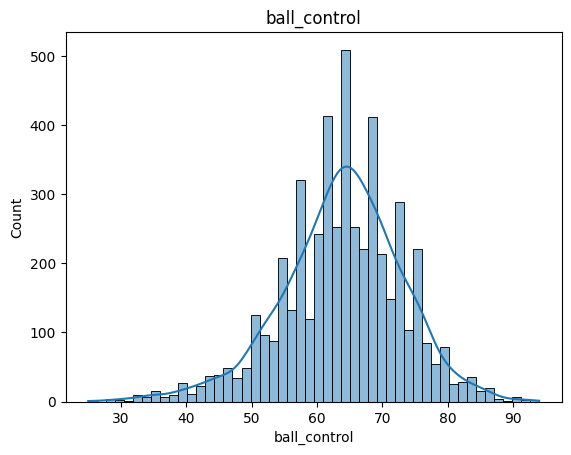

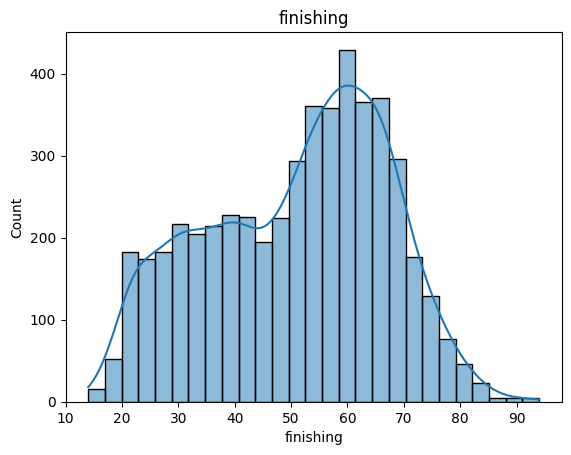

In [21]:
#univariate analysis
for col in imp_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Insights:


1.   The distribution of player value is highly right-skewed.
Most players have low to moderate value
Few players have very high value.
This indicates that only a small number of players are highly valued, which is typical in football markets
2.   Players in their prime age range dominate the dataset, which aligns with peak performance years.

1.  Reactions are normally distributed. This suggests a balanced spread of player awareness and responsiveness levels.
2.   Ball control is slightly left-skewed distribution. layers have good ball control.
It indicates that technical skills are generally well-developed among players.


1.   Some players have very low finishing, while few have very high finishing

1.   Univariate analysis shows that the target variable (value) is highly skewed, while performance-related features show varied distributions, indicating differences in player abilities and valuation.








In [22]:
import numpy as np

def clean_value(x):
    if isinstance(x, str):
        x = x.replace('$', '')

        # Case 1: if it has multiple dots → thousand separator
        if x.count('.') > 1:
            x = x.replace('.', '')
            return float(x)

        # Case 2: normal decimal value
        else:
            return float(x)

    return np.nan

# Apply function
df['value'] = df['value'].apply(clean_value)

Converted the value column from categorical to numerical format because it represents a continuous numeric variable, and machine learning models and statistical methods like correlation require numeric data for proper analysis.

In [23]:
df

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,Atl. Nacional,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,1400000.0
1,Brazil,181,80,31,Corinthians,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,975.0
3,Austria,187,86,33,SK Rapid Wien,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,650.0
6,Switzerland,194,88,25,BSC Young Boys,52,43,71,72,63,...,29,22,34,34,10,5,14,12,5,1600000.0
7,Portugal,185,75,20,Boavista FC,41,33,65,70,46,...,26,26,39,25,7,6,12,13,11,230.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,Liverpool,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,99500000.0
5678,Senegal,174,69,31,FC Bayern München,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,101000000.0
5679,Brazil,175,68,31,Paris SG,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,99500000.0
5680,Portugal,187,83,38,Al Nassr,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,31000000.0


In [24]:
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include = "object").columns

In [25]:
cat_cols

Index(['country', 'club'], dtype='object')

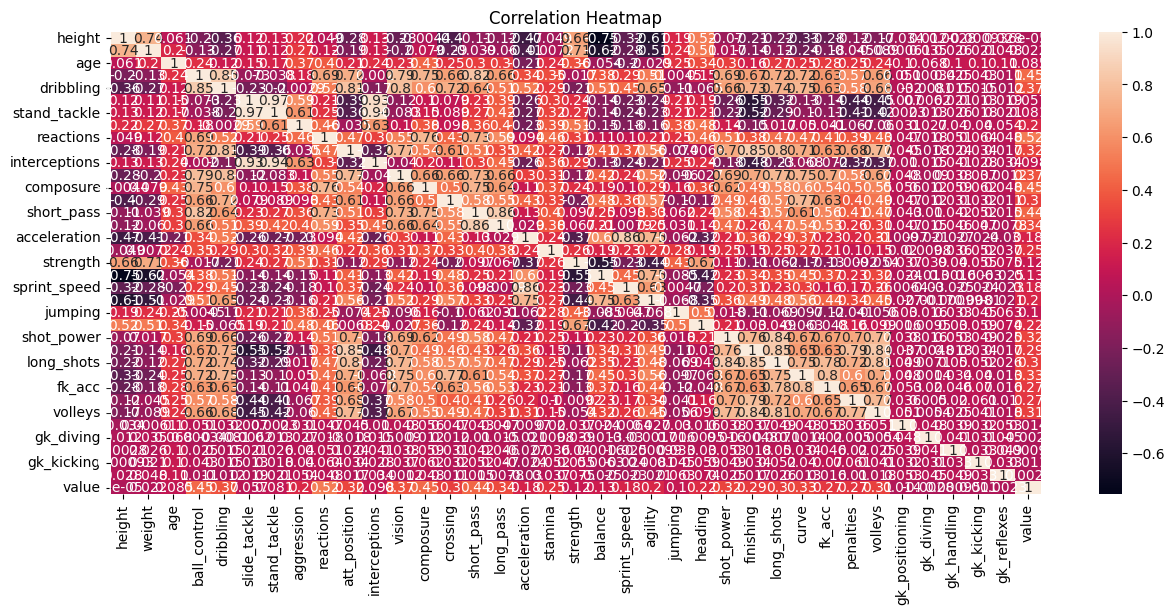

In [26]:
plt.figure(figsize=(15,6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Correlation analysis shows moderate relationships between features and player value, indicating that market value is influenced by multiple factors rather than a single variable.

In [27]:
#lael encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode club
df['club'] = le.fit_transform(df['club'])

# Encode country
df['country'] = le.fit_transform(df['country'])

In [28]:
df

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,24,192,84,22,62,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,1400000.0
1,14,181,80,31,153,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,975.0
3,8,187,86,33,534,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,650.0
6,120,194,88,25,74,52,43,71,72,63,...,29,22,34,34,10,5,14,12,5,1600000.0
7,100,185,75,20,90,41,33,65,70,46,...,26,26,39,25,7,6,12,13,11,230.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,37,175,71,31,382,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,99500000.0
5678,107,174,69,31,209,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,101000000.0
5679,14,175,68,31,453,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,99500000.0
5680,100,187,83,38,35,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,31000000.0


In [56]:
#split data into x and y
#applying log transformation
import numpy as np

X = df.drop('value',axis=1)
y = np.log1p(df['value'])


standardization


In [30]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

In [31]:
X_scaled

array([[-0.9867537 ,  1.71907271,  1.42199146, ..., -1.45253547,
        -1.09723927, -0.45536609],
       [-1.23385462,  0.03467879,  0.82504483, ...,  1.23734996,
        -0.76206395,  1.20448704],
       [-1.38211516,  0.95343911,  1.72046478, ..., -0.78006411,
         1.24898795, -0.45536609],
       ...,
       [-1.23385462, -0.88408153, -0.96579508, ..., -0.44382843,
         1.58416327,  0.20857516],
       [ 0.89121324,  0.95343911,  1.2727548 , ...,  0.22864293,
         1.58416327,  0.20857516],
       [ 1.36070497,  2.17845287,  4.10825132, ...,  1.57358564,
        -0.09171332,  0.54054579]])

In [32]:
from sklearn.decomposition import PCA

In [33]:
pca = PCA()

In [34]:
X_pca = pca.fit_transform(X_scaled)

In [35]:
X_pca.shape

(5047, 38)

In [36]:
## Explained variance

explained_variance = pca.explained_variance_ratio_

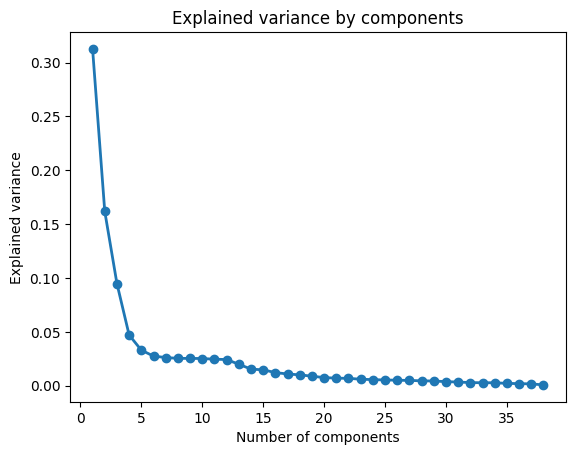

In [37]:
## Plot

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', linewidth=2)
plt.title('Explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.show()

Shows the individual variance contribution of each component


Cumulative variance plot

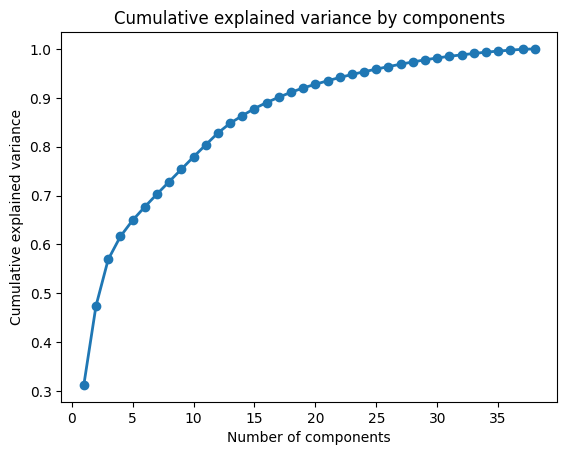

In [38]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-', linewidth=2)
plt.title('Cumulative explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

Shows total variance captured as components increase
More reliable for decision making

**Choose num of components where curve crosses 95% (Very important)**

In [39]:
## Select optimal component
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Optimal number of components: {n_components}")

Optimal number of components: 24


In [40]:
#apply PCA with 10 components
pca = PCA(n_components=24)

In [41]:
#transform data
X_pca = pca.fit_transform(X_scaled)

In [42]:
X_pca.shape

(5047, 24)

In [43]:
X_pca

array([[-5.94420872e+00,  2.78334182e+00, -1.49868820e+00, ...,
        -4.93746102e-01,  6.71704031e-01, -1.36313821e-01],
       [ 1.41177914e+00,  2.17118558e+00, -5.95628009e-01, ...,
         2.23080194e-01,  1.16090445e+00, -4.88858661e-01],
       [-5.87544476e+00,  3.48979118e+00, -4.48384963e-02, ...,
        -5.25160140e-01, -2.08487158e-01,  5.64143600e-02],
       ...,
       [ 1.09318754e+01,  3.08532710e-01, -3.09848511e-01, ...,
         9.23685152e-01, -8.53909845e-02, -5.20857071e-01],
       [ 8.90908933e+00,  2.93524067e+00, -4.52268620e+00, ...,
         6.89427128e-02,  2.23902583e-01, -3.51526903e-01],
       [ 6.36882988e+00,  4.17529586e+00, -6.82942007e+00, ...,
         8.21531116e-01,  9.32135687e-04, -9.40489627e-01]])

In [44]:
## Split the dataset into train_test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, train_size= 0.8)

In [45]:
# ML model building

from sklearn.ensemble import RandomForestRegressor

In [46]:
##a simpler/Vanilla version of RF classifier and then fine tune it using Grid search CV

rf = RandomForestRegressor()


In [47]:
bl_model = rf.fit(X_train, y_train)

In [63]:
bl_y_pred = bl_model.predict(X_test)


In [64]:
## Evalaution metrics

from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, bl_y_pred)
mse = mean_squared_error(y_test, bl_y_pred)



In [65]:
print("R2 Score:", r2)
print("MSE:", mse)


R2 Score: 0.7785820010825577
MSE: 4.464065218708126


After applying log transformation, the model performance improved significantly, with the R² score increasing from 0.70 to 0.78. The transformation helped in reducing skewness and stabilizing variance, allowing the model to learn patterns more effectively. The error reduced substantially on the transformed scale, indicating better predictive performance.

GridSearchCV: Hyperparameter tuning technique to find the optimal values of the parameters


In [66]:
## Define the parameter grid randomly (trail and error)

param_grid1 = {
    "n_estimators": [100, 150, 50],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

In [67]:
## Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [68]:
## Initialize the GridSearch

grid = GridSearchCV(estimator=rf, param_grid=param_grid1, cv=5)

In [69]:
## Train the gridsearch

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150, 50]})

In [55]:
## Best parameters

print("Best params: ", grid.best_params_)
print("Best CV score: ", grid.best_score_)

Best params:  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score:  0.7644179563138325


The model was trained using log-transformed target values to handle skewness in the data. Hyperparameter tuning using GridSearchCV resulted in an optimized Random Forest model with a cross-validation score of 0.76 and a test R² score of 0.78, indicating strong and consistent performance. The close alignment between cross-validation and test scores suggests that the model generalizes well and is not overfitting.